# 05 — LSTM Embeddings: Clustering & Interpretation

**Цель**: обучить LSTM-эмбеддер на задаче предсказания log-return,
получить low-dimensional представления окон через UMAP,
кластеризовать двумя способами (KMeans и HDBSCAN),
проинтерпретировать кластеры и выбрать лучший метод кластеризации.

**Pipeline**:
1. Загрузка и нарезка данных на окна
2. Обучение `LSTMEmbedder` (hidden state → embedding)
3. UMAP-проекция эмбеддингов
4. KMeans — подбор k, кластеризация
5. HDBSCAN — кластеризация + обработка шума
6. Интерпретация кластеров (профили, доходности, волатильность)
7. Количественное сравнение двух методов → выбор лучшего

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath("../../src"))
sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from data.dataloader import Dataloader
from data.tickers import TICKERS
from embeddings.LSTM_embedder import LSTMEmbedder
from clustering.kmeans import KMeansClusterer
from clustering.hdbscan import HDBSCANClusterer
from clustering.umap_reducer import UMAPProjector
from clustering.cluster_analysis import (
    elbow_scores, plot_elbow, plot_clusters_2d, cluster_stats,
)

WINDOW_SIZE = 60
STEP = WINDOW_SIZE
RANDOM_STATE = 42


np.random.seed(RANDOM_STATE)

FEATURE_COLS = [
    "open", "high", "low", "close", "volume",
    "sma5", "sma20", "ema12", "ema26", "close_sma20",
    "macd", "macd_signal", "macd_hist", "rsi14",
    "bb_pct", "bb_bw", "atr14", "obv",
]

print(f"Tickers: {len(TICKERS)}  |  Window: {WINDOW_SIZE}  |  Step: {STEP}")

245
Tickers: 245  |  Window: 60  |  Step: 60


## 1. Загрузка данных и нарезка на окна

In [ ]:
loader = Dataloader()

dataset = loader.cut_on_windows(
    TICKERS,
    seq_len=WINDOW_SIZE,
    step_size=STEP,
    feature_cols=FEATURE_COLS,
    path = "../../src/data/moex_candles"
)
print(f"Loaded {len(dataset)} / {len(TICKERS)} tickers")

X_train, y_train, X_val, y_val, X_test, y_test = loader.concat_splits(dataset)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Loaded 236 / 245 tickers
X_train: (9627, 60, 18)  y_train: (9627,)
X_val:   (1760, 60, 18)    y_val:   (1760,)
X_test:  (1306, 60, 18)   y_test:  (1306,)


## 2. Обучение LSTM-эмбеддера

LSTM обучается предсказывать log-return (следующий день).
После обучения hidden state последнего шага используется как эмбеддинг окна.

In [3]:
num_features = X_train.shape[2]

embedder = LSTMEmbedder(
    input_size=num_features,
    hidden_size=32,
    num_layers=2,
    dropout=0.1,
)
print(f"Device: {next(embedder.parameters()).device}")

train_raw_emb = embedder.fit_transform(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=50, batch_size=512, lr=1e-3,
)
val_raw_emb  = embedder.transform(X_val)
test_raw_emb = embedder.transform(X_test)

print(f"\nRaw LSTM embeddings — train: {train_raw_emb.shape}, "
      f"val: {val_raw_emb.shape}, test: {test_raw_emb.shape}")

Device: cuda:0
Epoch  10/50  train=0.001423  val=0.001074
Epoch  20/50  train=0.001416  val=0.001042
Epoch  30/50  train=0.001403  val=0.001085
Epoch  40/50  train=0.001387  val=0.001090
Epoch  50/50  train=0.001370  val=0.001112

Raw LSTM embeddings — train: (9627, 32), val: (1760, 32), test: (1306, 32)


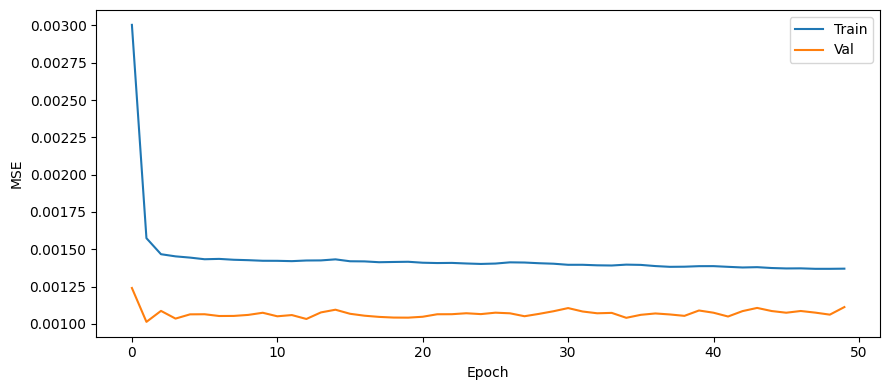

In [4]:
embedder.plot_loss()

## 3. UMAP — снижение размерности

LSTM-эмбеддинги (64-мерные) проецируются в 15-мерное пространство через UMAP.
UMAP fit только на train, transform на val/test.

In [5]:
UMAP_COMPONENTS = 15

In [6]:
umap_proj = UMAPProjector(n_components=UMAP_COMPONENTS, random_state=RANDOM_STATE)
train_embeddings = umap_proj.fit_transform(train_raw_emb)
val_embeddings   = umap_proj.transform(val_raw_emb)
test_embeddings  = umap_proj.transform(test_raw_emb)

print(f"UMAP embeddings — train: {train_embeddings.shape}, "
      f"val: {val_embeddings.shape}, test: {test_embeddings.shape}")

UMAP embeddings — train: (9627, 15), val: (1760, 15), test: (1306, 15)


## 4. KMeans — подбор числа кластеров и кластеризация

In [7]:
N_CLUSTERS_RANGE = range(2, 11)

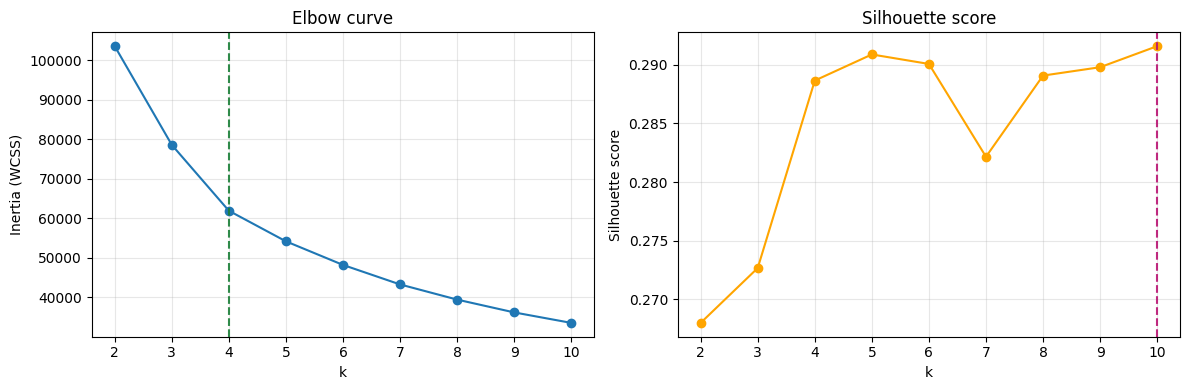

k_elbow (левый график):     4
k_silhouette (правый график): 10

Используем BEST_K=10  (silhouette@10=0.292)


In [8]:
scores = plot_elbow(train_embeddings, k_range=N_CLUSTERS_RANGE,
                    random_state=RANDOM_STATE)

print(f"k_elbow (левый график):     {scores['k_elbow']}")
print(f"k_silhouette (правый график): {scores['k_silhouette']}")

# KMeans ниже: отдельно elbow и silhouette — выберите, что важнее для задачи
BEST_K = scores["k_silhouette"]  # смените на scores["k_elbow"] при необходимости
i = scores["k"].index(BEST_K)
print(f"\nИспользуем BEST_K={BEST_K}  "
      f"(silhouette@{BEST_K}={scores['silhouette'][i]:.3f})")

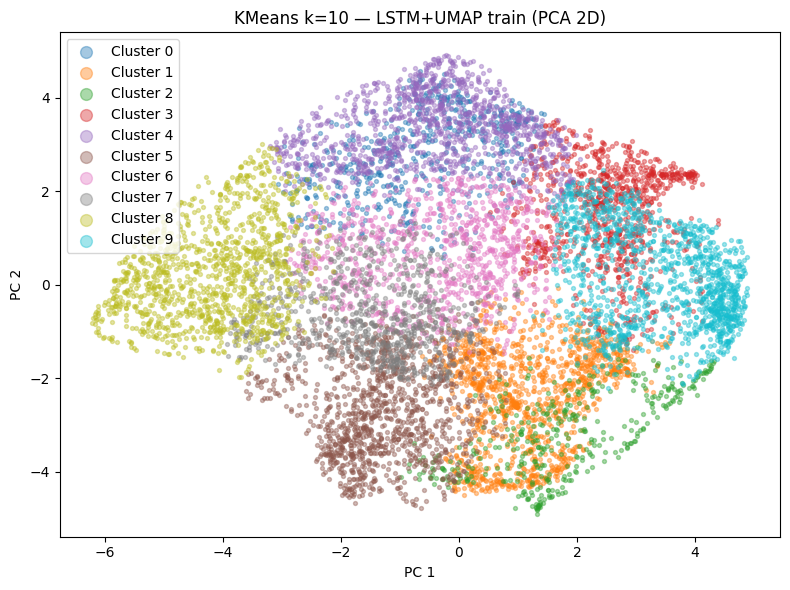

         count  return_mean  return_std  return_median        pct
cluster                                                          
0          566    -0.003708    0.041224      -0.002450   5.879298
1         1236    -0.000320    0.042993       0.000000  12.838891
2          406    -0.003978    0.044651       0.000000   4.217305
3          913     0.000068    0.041629       0.000000   9.483744
4         1130    -0.000779    0.031716       0.000000  11.737821
5         1145    -0.000594    0.027222       0.000000  11.893632
6          946    -0.000654    0.040448       0.000000   9.826530
7          803    -0.002116    0.043438      -0.000592   8.341124
8         1195     0.000213    0.031380       0.000000  12.413005
9         1287     0.001910    0.038382       0.000000  13.368651


In [9]:
kmeans = KMeansClusterer(n_clusters=BEST_K, random_state=RANDOM_STATE, scale=True)
kmeans.fit(train_embeddings)

km_train_labels = kmeans.labels_
km_val_labels   = kmeans.predict(val_embeddings)
km_test_labels  = kmeans.predict(test_embeddings)

plot_clusters_2d(train_embeddings, km_train_labels,
                 title=f"KMeans k={BEST_K} — LSTM+UMAP train (PCA 2D)")

km_stats = cluster_stats(km_train_labels, y_train)
print(km_stats)

## 5. HDBSCAN — кластеризация + обработка шума

In [10]:
hdb = HDBSCANClusterer(min_cluster_size=50, scale=True, prediction_data=True)
hdb.fit(train_embeddings)

hdb_train_labels = hdb.labels_
n_clusters_hdb = hdb.n_clusters_
noise_pct = hdb.noise_ratio_ * 100
print(f"HDBSCAN: {n_clusters_hdb} clusters, noise: {noise_pct:.1f}%")

non_noise_mask = hdb_train_labels != -1
knn_hdb = None
if non_noise_mask.sum() > 0:
    knn_hdb = KNeighborsClassifier(n_neighbors=5)
    knn_hdb.fit(train_embeddings[non_noise_mask], hdb_train_labels[non_noise_mask])


def _hdb_predict_and_fix(embeddings, label=""):
    from hdbscan import approximate_predict
    scaled = StandardScaler().fit(train_embeddings).transform(embeddings)
    raw_labels, _ = approximate_predict(hdb._hdbscan, scaled)
    raw_labels = np.asarray(raw_labels, dtype=np.int64)
    labels_fixed = raw_labels.copy()
    noise_mask = raw_labels == -1
    if knn_hdb is not None and noise_mask.sum() > 0:
        labels_fixed[noise_mask] = knn_hdb.predict(embeddings[noise_mask])
        print(f"  Reassigned {noise_mask.sum()} noise {label} points via KNN")
    return labels_fixed


hdb_train_labels_fixed = hdb_train_labels.copy()
noise_train_mask = hdb_train_labels == -1
if knn_hdb is not None and noise_train_mask.sum() > 0:
    hdb_train_labels_fixed[noise_train_mask] = knn_hdb.predict(
        train_embeddings[noise_train_mask]
    )
    print(f"  Reassigned {noise_train_mask.sum()} noise train points via KNN")

hdb_val_labels  = _hdb_predict_and_fix(val_embeddings, "val")
hdb_test_labels = _hdb_predict_and_fix(test_embeddings, "test")

HDBSCAN: 14 clusters, noise: 62.4%
  Reassigned 6009 noise train points via KNN
  Reassigned 1153 noise val points via KNN
  Reassigned 836 noise test points via KNN


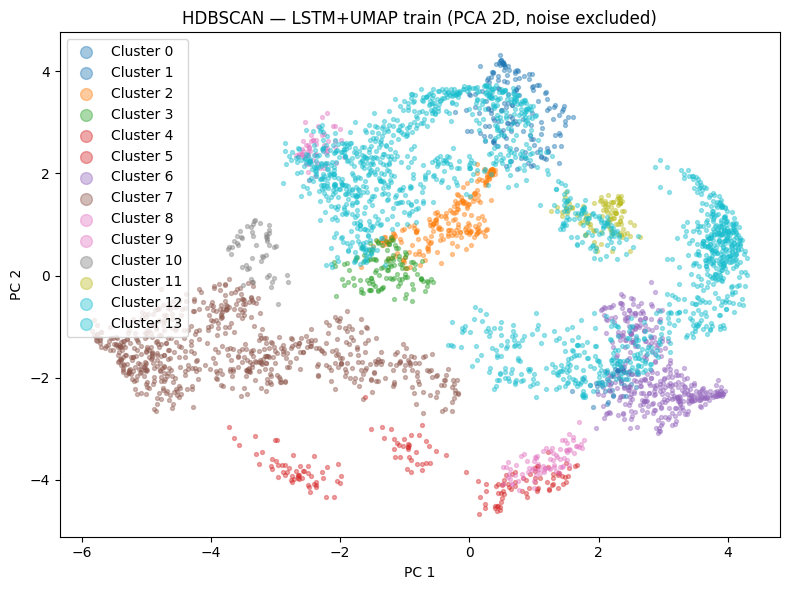

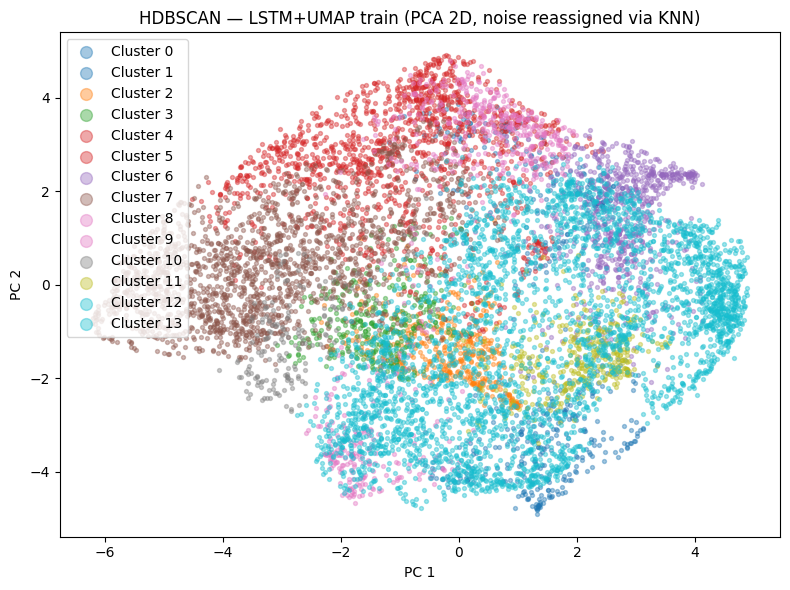

         count  return_mean  return_std  return_median        pct
cluster                                                          
0          298    -0.005418    0.039484       0.000000   3.095461
1          224    -0.000431    0.046080       0.000000   2.326789
2          437     0.001920    0.057334      -0.000402   4.539317
3          369    -0.004035    0.043578      -0.002270   3.832970
4          629    -0.001141    0.027713       0.000000   6.533707
5          710    -0.002600    0.041618      -0.001901   7.375091
6          678    -0.000019    0.042452       0.000000   7.042692
7         1709    -0.001041    0.036775      -0.000548  17.752155
8          425    -0.000189    0.029024      -0.000351   4.414667
9          225     0.000434    0.038505      -0.001234   2.337177
10         178    -0.000728    0.028163       0.000000   1.848966
11         382    -0.001170    0.046996       0.000000   3.968007
12        1652    -0.000827    0.030326       0.000000  17.160071
13        

In [11]:
if non_noise_mask.sum() > 0:
    plot_clusters_2d(
        train_embeddings[non_noise_mask],
        hdb_train_labels[non_noise_mask],
        title="HDBSCAN — LSTM+UMAP train (PCA 2D, noise excluded)",
    )

plot_clusters_2d(
    train_embeddings,
    hdb_train_labels_fixed,
    title="HDBSCAN — LSTM+UMAP train (PCA 2D, noise reassigned via KNN)",
)

hdb_stats = cluster_stats(hdb_train_labels_fixed, y_train)
print(hdb_stats)

## 6. Интерпретация кластеров

Для каждого кластера анализируем:
- Средний ценовой профиль (close) ± std
- Распределение log-return (target)
- Внутриоконная волатильность (std close внутри окна)
- Текстовая классификация: trending up / down / sideways, high / low vol

In [12]:
CLOSE_COL = FEATURE_COLS.index("close")


def interpret_clusters(X_windows, y, labels, title_prefix=""):
    cluster_ids = sorted(set(labels[labels >= 0]))
    n = len(cluster_ids)
    if n == 0:
        print("No clusters to interpret.")
        return

    fig, axes = plt.subplots(n, 3, figsize=(16, 4 * n), squeeze=False)

    for i, cid in enumerate(cluster_ids):
        mask = labels == cid
        windows = X_windows[mask]
        returns = y[mask]
        close_profiles = windows[:, :, CLOSE_COL]

        mean_prof = close_profiles.mean(axis=0)
        std_prof = close_profiles.std(axis=0)
        t = np.arange(len(mean_prof))

        ax0 = axes[i, 0]
        ax0.plot(t, mean_prof, "b-", lw=2)
        ax0.fill_between(t, mean_prof - std_prof, mean_prof + std_prof, alpha=0.2)
        ax0.set_title(f"{title_prefix}Cluster {cid} — mean close profile\n"
                      f"n={mask.sum()}")
        ax0.set_xlabel("Time step")

        ax1 = axes[i, 1]
        ax1.hist(returns, bins=50, edgecolor="k", alpha=0.7)
        ax1.axvline(returns.mean(), color="r", ls="--",
                    label=f"mean={returns.mean():.5f}")
        ax1.set_title("Return distribution")
        ax1.legend()

        ax2 = axes[i, 2]
        vols = close_profiles.std(axis=1)
        ax2.hist(vols, bins=50, edgecolor="k", alpha=0.7, color="orange")
        ax2.set_title("Intra-window volatility (close std)")

    plt.tight_layout()
    plt.show()

    vol_medians = []
    for cid in cluster_ids:
        mask = labels == cid
        vol_medians.append(X_windows[mask][:, :, CLOSE_COL].std(axis=1).mean())
    vol_global_median = float(np.median(vol_medians))

    print(f"\n{title_prefix}Cluster interpretation:")
    for idx, cid in enumerate(cluster_ids):
        mask = labels == cid
        ret = y[mask]
        vol = vol_medians[idx]
        regime = ("trending up" if ret.mean() > 0.001 else
                  "trending down" if ret.mean() < -0.001 else "sideways")
        vol_label = "high vol" if vol > vol_global_median else "low vol"
        print(f"  Cluster {cid}: n={mask.sum():>6}, mean_ret={ret.mean():+.5f}, "
              f"std_ret={ret.std():.5f}, {regime}, {vol_label}")

KMeans clusters


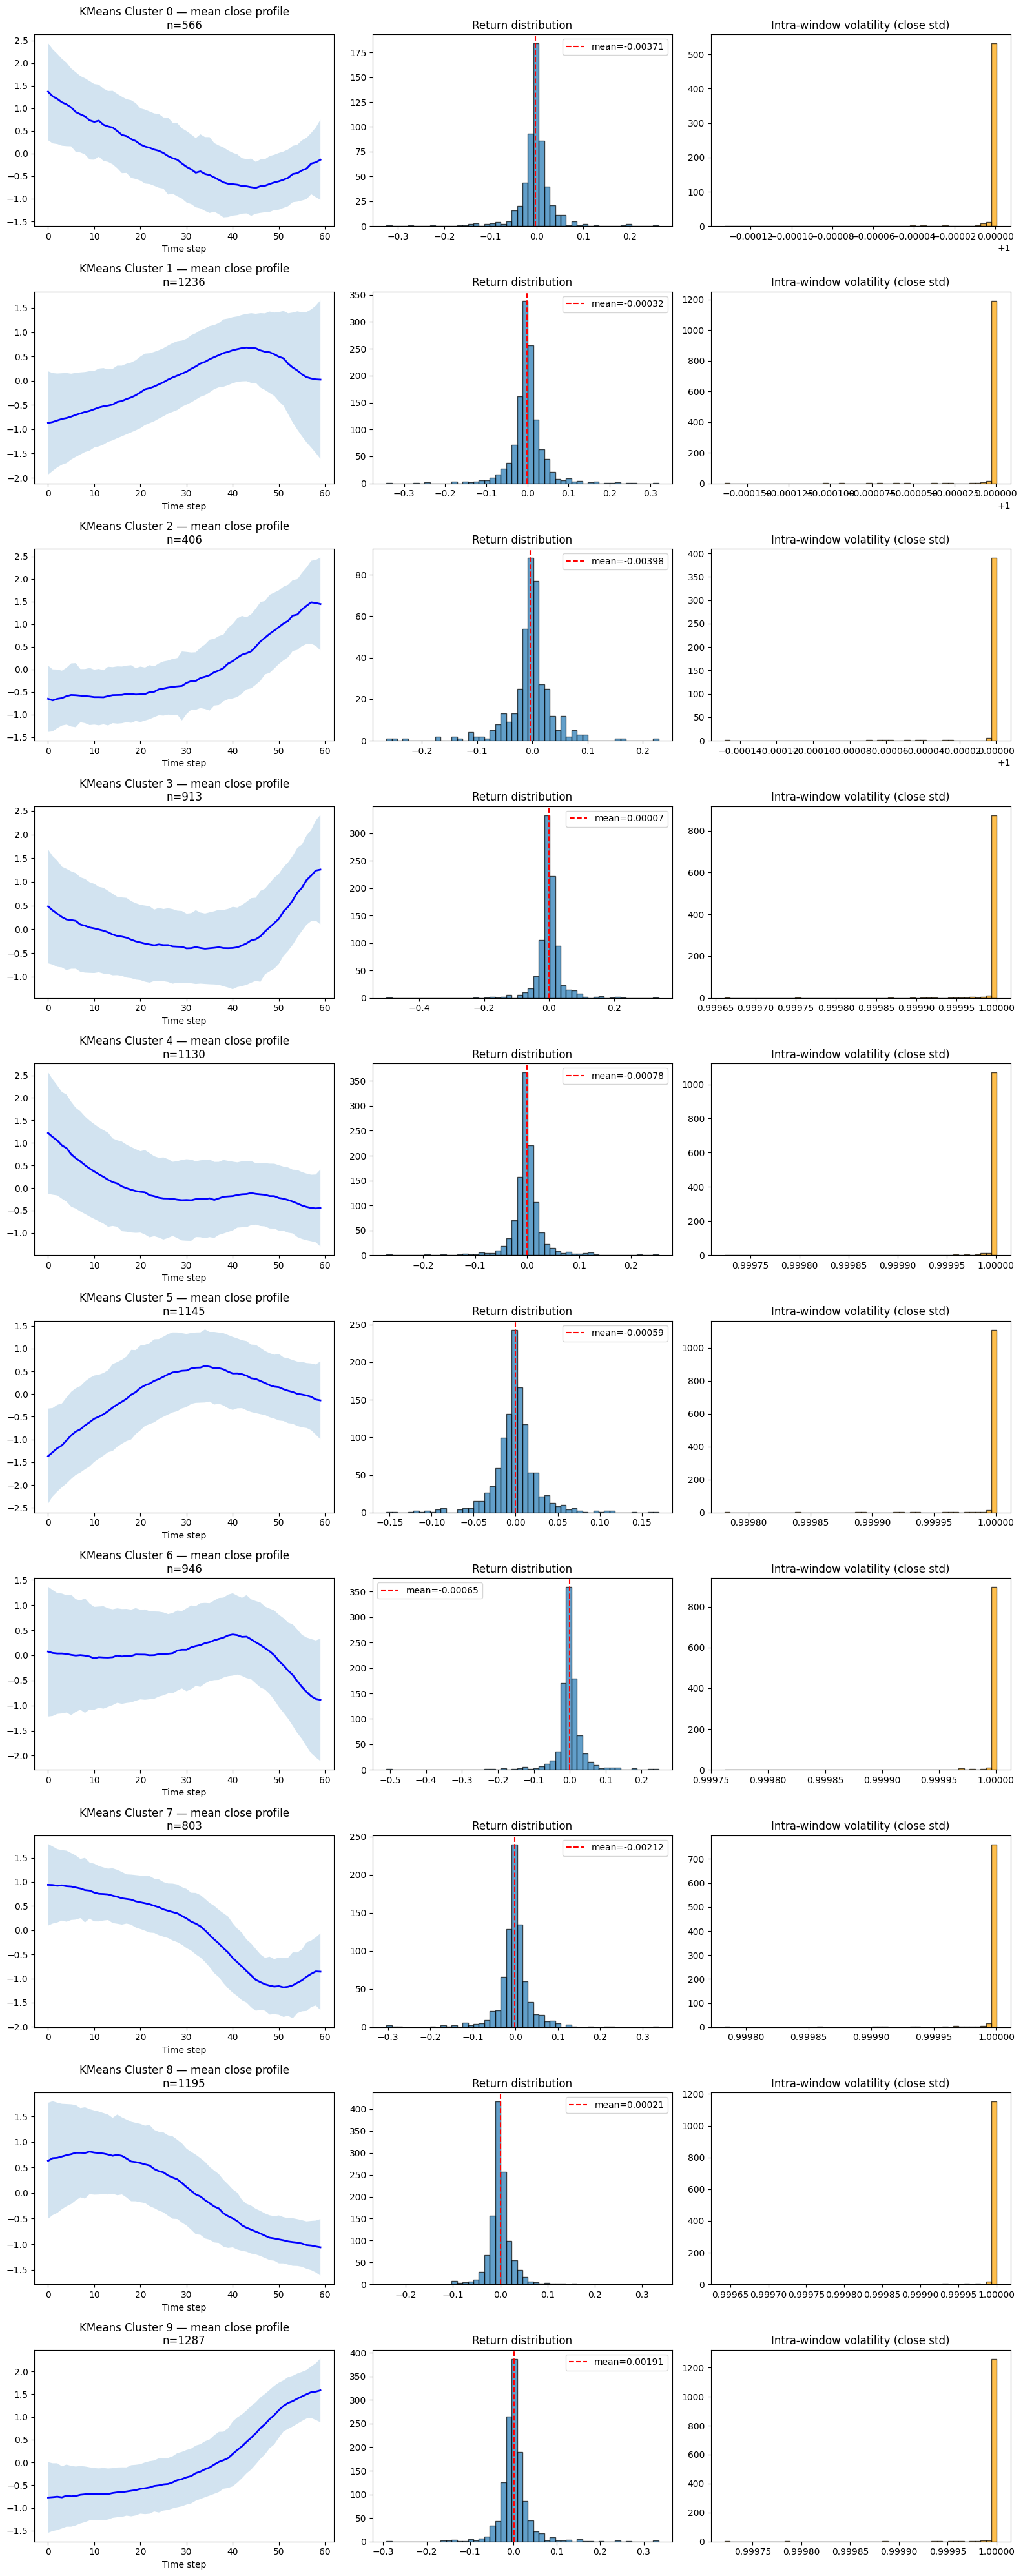


KMeans Cluster interpretation:
  Cluster 0: n=   566, mean_ret=-0.00371, std_ret=0.04122, trending down, high vol
  Cluster 1: n=  1236, mean_ret=-0.00032, std_ret=0.04299, sideways, high vol
  Cluster 2: n=   406, mean_ret=-0.00398, std_ret=0.04465, trending down, high vol
  Cluster 3: n=   913, mean_ret=+0.00007, std_ret=0.04163, sideways, low vol
  Cluster 4: n=  1130, mean_ret=-0.00078, std_ret=0.03172, sideways, low vol
  Cluster 5: n=  1145, mean_ret=-0.00059, std_ret=0.02722, sideways, high vol
  Cluster 6: n=   946, mean_ret=-0.00065, std_ret=0.04045, sideways, low vol
  Cluster 7: n=   803, mean_ret=-0.00212, std_ret=0.04344, trending down, low vol
  Cluster 8: n=  1195, mean_ret=+0.00021, std_ret=0.03138, sideways, low vol
  Cluster 9: n=  1287, mean_ret=+0.00191, std_ret=0.03838, trending up, high vol


In [13]:
print("=" * 60)
print("KMeans clusters")
print("=" * 60)
interpret_clusters(X_train, y_train, km_train_labels, title_prefix="KMeans ")

HDBSCAN clusters


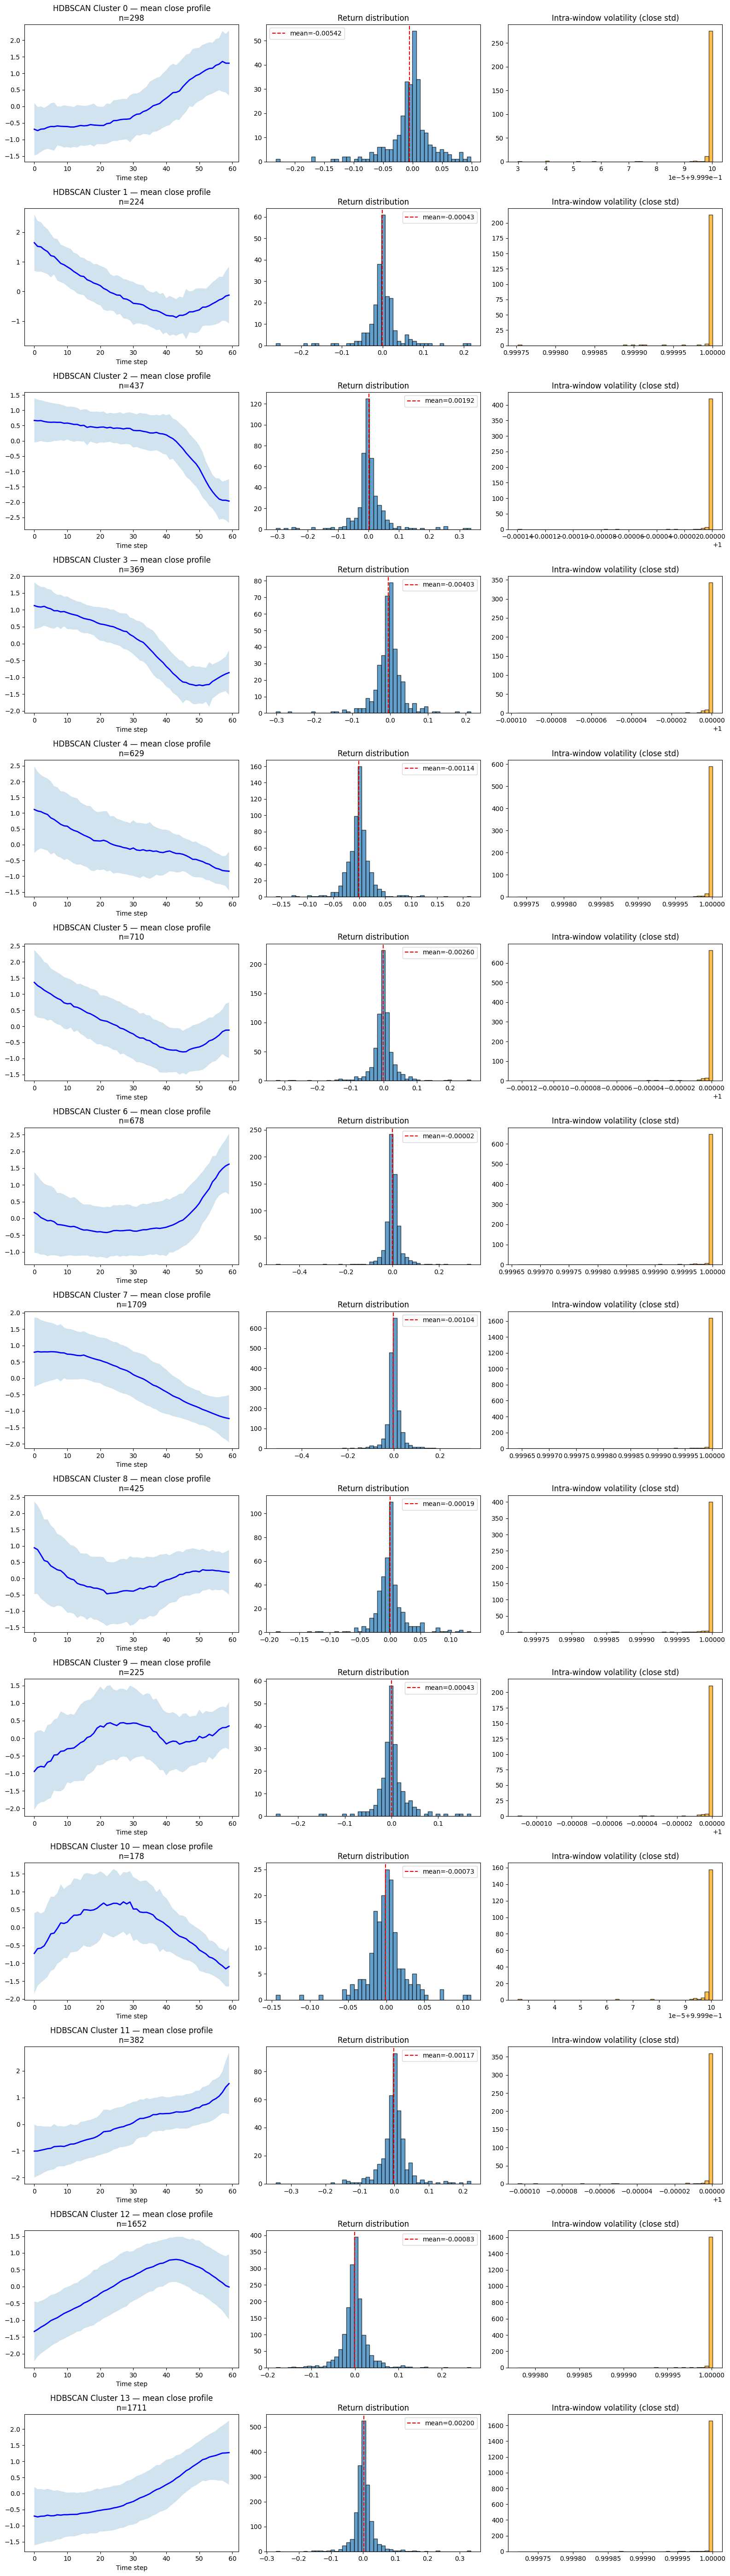


HDBSCAN Cluster interpretation:
  Cluster 0: n=   298, mean_ret=-0.00542, std_ret=0.03948, trending down, low vol
  Cluster 1: n=   224, mean_ret=-0.00043, std_ret=0.04608, sideways, low vol
  Cluster 2: n=   437, mean_ret=+0.00192, std_ret=0.05733, trending up, high vol
  Cluster 3: n=   369, mean_ret=-0.00403, std_ret=0.04358, trending down, high vol
  Cluster 4: n=   629, mean_ret=-0.00114, std_ret=0.02771, trending down, low vol
  Cluster 5: n=   710, mean_ret=-0.00260, std_ret=0.04162, trending down, high vol
  Cluster 6: n=   678, mean_ret=-0.00002, std_ret=0.04245, sideways, low vol
  Cluster 7: n=  1709, mean_ret=-0.00104, std_ret=0.03677, trending down, low vol
  Cluster 8: n=   425, mean_ret=-0.00019, std_ret=0.02902, sideways, low vol
  Cluster 9: n=   225, mean_ret=+0.00043, std_ret=0.03850, sideways, high vol
  Cluster 10: n=   178, mean_ret=-0.00073, std_ret=0.02816, sideways, high vol
  Cluster 11: n=   382, mean_ret=-0.00117, std_ret=0.04700, trending down, high vol
  

In [14]:
print("=" * 60)
print("HDBSCAN clusters")
print("=" * 60)
interpret_clusters(X_train, y_train, hdb_train_labels_fixed, title_prefix="HDBSCAN ")

## 7. Количественное сравнение KMeans vs HDBSCAN

Метрики качества кластеризации:
- **Silhouette** (↑ лучше): насколько объекты похожи на свой кластер vs соседний
- **Calinski-Harabasz** (↑ лучше): отношение межкластерной к внутрикластерной дисперсии
- **Davies-Bouldin** (↓ лучше): средняя похожесть каждого кластера на ближайший
- **Межкластерная дисперсия mean return**: разброс средних доходностей между кластерами (↑ = кластеры лучше разделяют режимы рынка)

In [15]:
emb_scaled = StandardScaler().fit_transform(train_embeddings)

def clustering_quality(labels, name):
    valid = labels >= 0
    n_clusters = len(set(labels[valid]))
    if n_clusters < 2:
        print(f"{name}: fewer than 2 clusters, skipping metrics")
        return None

    X_valid = emb_scaled[valid]
    l_valid = labels[valid]

    sil = silhouette_score(X_valid, l_valid)
    ch  = calinski_harabasz_score(X_valid, l_valid)
    db  = davies_bouldin_score(X_valid, l_valid)

    cluster_ids = sorted(set(l_valid))
    mean_rets = [y_train[labels == c].mean() for c in cluster_ids]
    ret_spread = np.std(mean_rets)

    noise_pct = (1 - valid.mean()) * 100

    return {
        "method": name,
        "n_clusters": n_clusters,
        "noise_%": f"{noise_pct:.1f}",
        "silhouette": round(sil, 4),
        "calinski_harabasz": round(ch, 1),
        "davies_bouldin": round(db, 4),
        "return_spread": round(ret_spread, 6),
    }


rows = [
    clustering_quality(km_train_labels, "KMeans"),
    clustering_quality(hdb_train_labels, "HDBSCAN (raw)"),
    clustering_quality(hdb_train_labels_fixed, "HDBSCAN (KNN-fixed)"),
]
rows = [r for r in rows if r is not None]

comparison = pd.DataFrame(rows).set_index("method")
print(comparison.to_string())

                     n_clusters noise_%  silhouette  calinski_harabasz  davies_bouldin  return_spread
method                                                                                               
KMeans                       10     0.0      0.2916             3536.5          1.0963       0.001712
HDBSCAN (raw)                14    62.4      0.2682             1056.0          0.8882       0.002095
HDBSCAN (KNN-fixed)          14     0.0      0.1142             1737.7          1.3462       0.001945


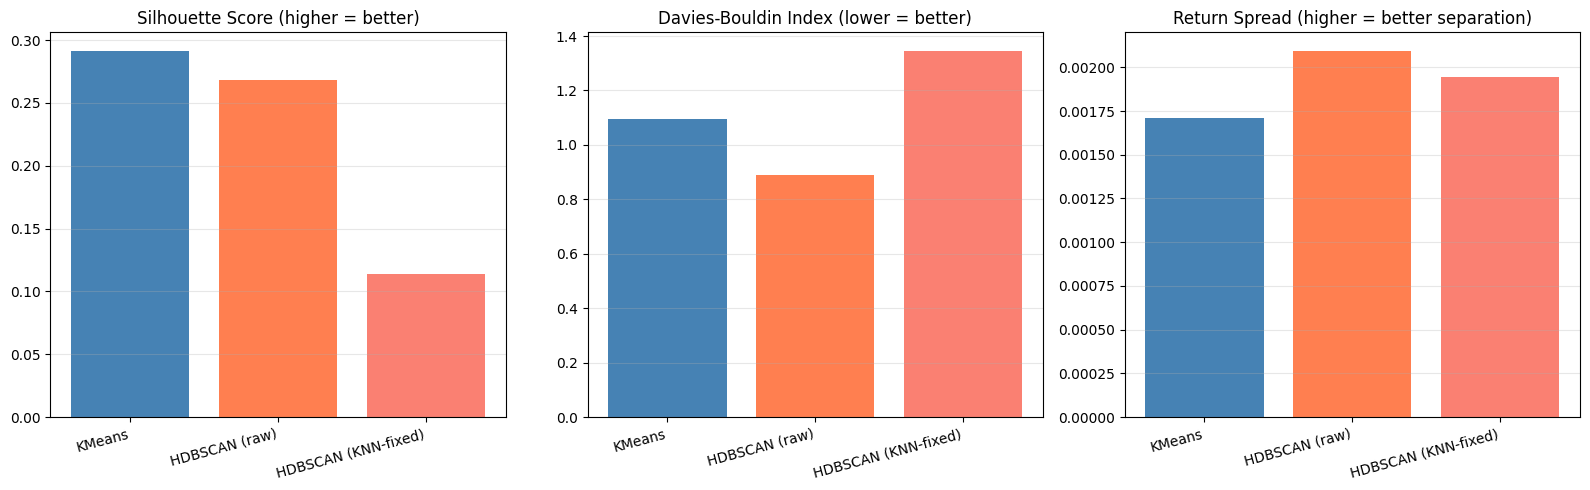

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

methods = comparison.index.tolist()
x = np.arange(len(methods))

axes[0].bar(x, comparison["silhouette"], color=["steelblue", "coral", "salmon"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=15, ha="right")
axes[0].set_title("Silhouette Score (higher = better)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x, comparison["davies_bouldin"], color=["steelblue", "coral", "salmon"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=15, ha="right")
axes[1].set_title("Davies-Bouldin Index (lower = better)")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(x, comparison["return_spread"], color=["steelblue", "coral", "salmon"])
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=15, ha="right")
axes[2].set_title("Return Spread (higher = better separation)")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Стабильность кластеризации на val/test

In [17]:
def split_consistency(labels_train, labels_other, y_train, y_other, name, split_name):
    """Сравниваем характеристики кластеров на train vs другом сплите."""
    cluster_ids = sorted(set(labels_train[labels_train >= 0]))
    rows = []
    for cid in cluster_ids:
        m_tr = labels_train == cid
        m_ot = labels_other == cid
        rows.append({
            "cluster": cid,
            "train_n": int(m_tr.sum()),
            f"{split_name}_n": int(m_ot.sum()),
            "train_mean_ret": float(y_train[m_tr].mean()) if m_tr.sum() > 0 else np.nan,
            f"{split_name}_mean_ret": float(y_other[m_ot].mean()) if m_ot.sum() > 0 else np.nan,
        })
    df = pd.DataFrame(rows).set_index("cluster")
    df["ret_drift"] = abs(df["train_mean_ret"] - df[f"{split_name}_mean_ret"])
    print(f"\n{name} — train vs {split_name}:")
    print(df.to_string())
    print(f"  Mean absolute ret drift: {df['ret_drift'].mean():.6f}")
    return df


km_val_drift  = split_consistency(km_train_labels, km_val_labels, y_train, y_val, "KMeans", "val")
km_test_drift = split_consistency(km_train_labels, km_test_labels, y_train, y_test, "KMeans", "test")

hdb_val_drift  = split_consistency(hdb_train_labels_fixed, hdb_val_labels, y_train, y_val, "HDBSCAN", "val")
hdb_test_drift = split_consistency(hdb_train_labels_fixed, hdb_test_labels, y_train, y_test, "HDBSCAN", "test")


KMeans — train vs val:
         train_n  val_n  train_mean_ret  val_mean_ret  ret_drift
cluster                                                         
0            566     94       -0.003708     -0.008150   0.004441
1           1236    348       -0.000320      0.001373   0.001693
2            406     24       -0.003978      0.005057   0.009035
3            913    109        0.000068      0.001238   0.001170
4           1130    181       -0.000779     -0.010702   0.009923
5           1145    205       -0.000594     -0.002932   0.002338
6            946    282       -0.000654      0.005218   0.005872
7            803     75       -0.002116     -0.004831   0.002715
8           1195    218        0.000213     -0.002652   0.002866
9           1287    224        0.001910     -0.005482   0.007392
  Mean absolute ret drift: 0.004745

KMeans — train vs test:
         train_n  test_n  train_mean_ret  test_mean_ret  ret_drift
cluster                                                           
0

## 9. Вывод

In [18]:
print("=" * 60)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("=" * 60)
print()
print(comparison.to_string())
print()

km_sil  = comparison.loc["KMeans", "silhouette"]
hdb_sil = comparison.loc["HDBSCAN (KNN-fixed)", "silhouette"] if "HDBSCAN (KNN-fixed)" in comparison.index else 0
km_db   = comparison.loc["KMeans", "davies_bouldin"]
hdb_db  = comparison.loc["HDBSCAN (KNN-fixed)", "davies_bouldin"] if "HDBSCAN (KNN-fixed)" in comparison.index else 999
km_rs   = comparison.loc["KMeans", "return_spread"]
hdb_rs  = comparison.loc["HDBSCAN (KNN-fixed)", "return_spread"] if "HDBSCAN (KNN-fixed)" in comparison.index else 0

km_score  = (km_sil > hdb_sil) + (km_db < hdb_db) + (km_rs > hdb_rs)
hdb_score = (hdb_sil > km_sil) + (hdb_db < km_db) + (hdb_rs > km_rs)

if km_score > hdb_score:
    winner = "KMeans"
elif hdb_score > km_score:
    winner = "HDBSCAN"
else:
    winner = "Tie"

print(f"KMeans wins {km_score}/3 metrics, HDBSCAN wins {hdb_score}/3 metrics")
print(f"\n>>> Лучший метод кластеризации: {winner}")

ИТОГОВОЕ СРАВНЕНИЕ

                     n_clusters noise_%  silhouette  calinski_harabasz  davies_bouldin  return_spread
method                                                                                               
KMeans                       10     0.0      0.2916             3536.5          1.0963       0.001712
HDBSCAN (raw)                14    62.4      0.2682             1056.0          0.8882       0.002095
HDBSCAN (KNN-fixed)          14     0.0      0.1142             1737.7          1.3462       0.001945

KMeans wins True/3 metrics, HDBSCAN wins True/3 metrics

>>> Лучший метод кластеризации: Tie
